In [1]:
from pathlib import Path
from random import random

import matplotlib.pyplot as plt
import numpy as np
from umap import UMAP
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "glomeruli" / "embeddings"

# Input modificabili
DATASET_PATHS = {
    "masked": EMBEDDINGS_DIR / "densenet_crops_embeddings.npy",
   # "unmasked": EMBEDDINGS_DIR / "nasnet_unmasked_embeddings.npy",
}
PCA_VARIANCES = 0.95
RANDOM_STATE = 42

2026-06-26 10:03:26.067804: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def fit_pca(x, n_components = 0.95):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(x)
    pca = PCA(n_components=n_components)
    return pca.fit_transform(scaled)

def fit_umap(
        x,
        n_components,
        n_neighbors = 15,
        random_state = RANDOM_STATE,
        min_dist = 0.0,
):
    umap = UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        #random_state=random_state,
        metric="euclidean",
    )

    return umap.fit_transform(x)

def plot_pca_umap_square(
    masked_pca,
    #unmasked_pca,
    masked_umap,
    #unmasked_umap,
    labels_masked=None,
    labels_unmasked=None,
    s=5,
    alpha=0.7,
    cmap="viridis"
):
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    plots = [
        #(masked_pca,   labels_masked,   "Masked PCA",   axes[0, 0]),
        #(unmasked_pca, labels_unmasked, "Unmasked PCA", axes[0, 1]),
        (masked_umap,  labels_masked,   "Masked UMAP",  axes[0, 0]),
        #(unmasked_umap,labels_unmasked, "Unmasked UMAP",axes[1, 1]),
    ]

    for emb, labels, title, ax in plots:
        if labels is not None:
            sc = ax.scatter(
                emb[:, 0],
                emb[:, 1],
                c=labels,
                s=s,
                alpha=alpha,
                cmap=cmap,
                linewidths=0
            )
        else:
            ax.scatter(
                emb[:, 0],
                emb[:, 1],
                s=s,
                alpha=alpha,
                linewidths=0
            )

        ax.set_title(title)
        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
        ax.set_aspect("equal", adjustable="datalim")

    plt.tight_layout()
    plt.show()

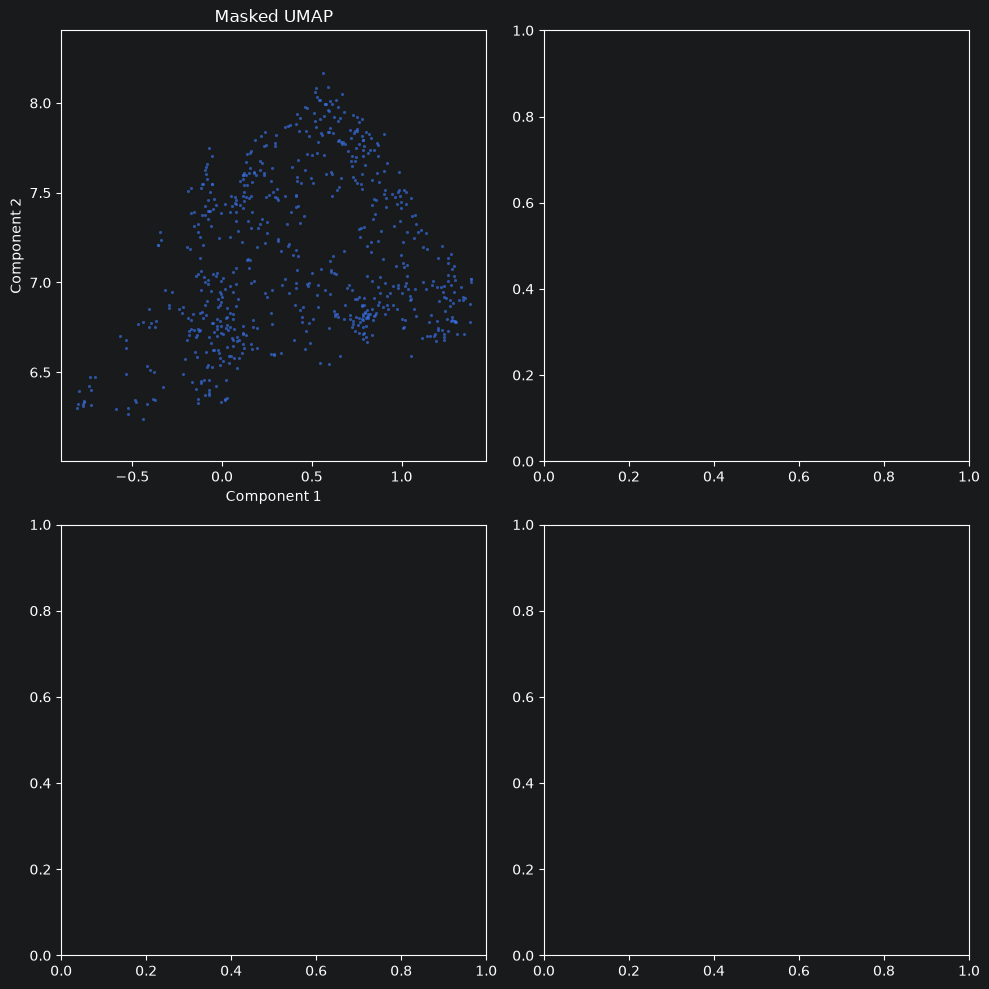

In [10]:
masked = np.load(DATASET_PATHS["masked"])
#unmasked = np.load(DATASET_PATHS["unmasked"])

masked_pca = fit_pca(masked)
#unmasked_pca = fit_pca(unmasked)

masked_umap = fit_umap(masked, 20,50)
#unmasked_umap = fit_umap(unmasked, 2)

plot_pca_umap_square(
    masked_pca,
    #unmasked_pca,
    masked_umap,
    #unmasked_umap
)


In [ ]:
import plotly.graph_objects as go


def plot_umap_3d(emb_umap, title):
    """
    Visualizza un embedding UMAP 3D in modo dinamico/interattivo.

    emb_umap deve avere shape:
    (numero_immagini, 3)
    """

    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=emb_umap[:, 0],
                y=emb_umap[:, 1],
                z=emb_umap[:, 2],
                mode="markers",
                marker=dict(
                    size=4,
                    opacity=0.75
                )
            )
        ]
    )

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="UMAP 1",
            yaxis_title="UMAP 2",
            zaxis_title="UMAP 3"
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()

In [ ]:
plot_umap_3d(unmasked_umap_3, "Unmasked glomeruli")dinov2_large_patchmasked_umap_3 = fit_umap(masked, 3)
unmasked_umap_3 = fit_umap(unmasked, 3)

plot_umap_3d(masked_umap_3, "Masked glomeruli")


In [ ]:
plot_umap_3d(unmasked_umap_3, "Unmasked glomeruli")

In [12]:
from sklearn.neighbors import NearestNeighbors


def compute_nearest_neighbors(
        X: np.ndarray,
        n_neighbors: int = 6,
        metric: str = "cosine"
):
    nn = NearestNeighbors(
        n_neighbors=n_neighbors,
        metric=metric
    )

    nn.fit(X)

    distances, indices = nn.kneighbors(X)

    return distances, indices

In [15]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


def show_nearest_neighbors_from_csv(
        query_idx: int,
        indices,
        distances,
        metadata: pd.DataFrame,
        image_path_column: str = "image_path",
        base_dir: str | Path | None = None,
        n_neighbors: int = 6,
        figsize_per_image: float = 2.2,
):
    """
    Mostra il glomerulo query e i suoi vicini più simili.

    Usa il CSV per recuperare i path delle immagini.

    Assunzione:
        riga i del CSV = embeddings[i]
    """

    if base_dir is not None:
        base_dir = Path(base_dir)
        print(f"Base directory: {base_dir.resolve()}")

    neighbor_indices = indices[query_idx][:n_neighbors]
    neighbor_distances = distances[query_idx][:n_neighbors]

    fig, axes = plt.subplots(
        1,
        n_neighbors,
        figsize=(figsize_per_image * n_neighbors, figsize_per_image + 0.8)
    )

    if n_neighbors == 1:
        axes = [axes]

    for position, (neighbor_idx, distance) in enumerate(
            zip(neighbor_indices, neighbor_distances)
    ):
        image_path = Path(metadata.iloc[neighbor_idx][image_path_column])

        if base_dir is not None and not image_path.is_absolute():
            image_path = base_dir / image_path

        image = Image.open(image_path).convert("RGB")

        axes[position].imshow(image)
        axes[position].axis("off")

        if position == 0:
            title = f"QUERY\nidx={neighbor_idx}\nd={distance:.3f}"
        else:
            title = f"idx={neighbor_idx}\nd={distance:.3f}"

        axes[position].set_title(title, fontsize=9)

    plt.tight_layout()
    plt.show()

In [16]:
import pandas as pd
import numpy as np

metadata = pd.read_csv("/home/pasquale/PycharmProjects/Glomeruli-FP03-2026/data/glomeruli/embeddings/dinov2_base_patch_embeddings.csv")


Base directory: /home/pasquale/PycharmProjects/Glomeruli-FP03-2026


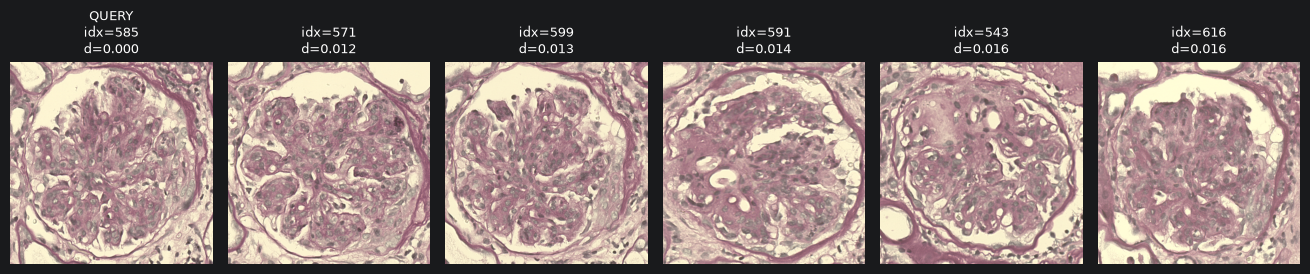

In [32]:
from random import Random

N_NEIGHBORS = 6
RNG = Random().randrange(0, len(metadata), 1)

distances, indices = compute_nearest_neighbors(
    X=masked,
    n_neighbors=N_NEIGHBORS,
    metric="cosine"
)
show_nearest_neighbors_from_csv(
    query_idx=RNG,
    indices=indices,
    distances=distances,
    metadata=metadata,
    image_path_column="image_path",
    base_dir="/home/pasquale/PycharmProjects/Glomeruli-FP03-2026",
    n_neighbors=N_NEIGHBORS
)